        sensor       channel    x_m    y_m  rel_elev_m
0  Seismometer     HHE/HN/HZ   0.00   0.00        0.00
1          HD1  Infrasound 1  -4.13  22.64       -0.12
2          HD2  Infrasound 2   7.85 -15.03       -0.23
3          HD3  Infrasound 3 -18.09  -1.25        0.17


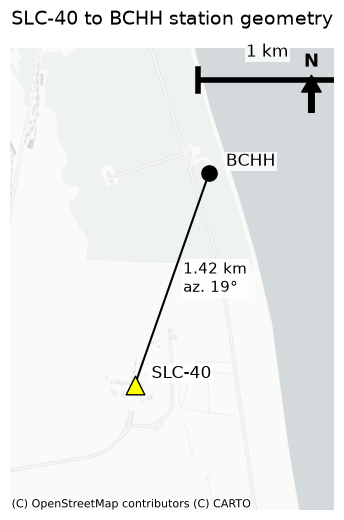

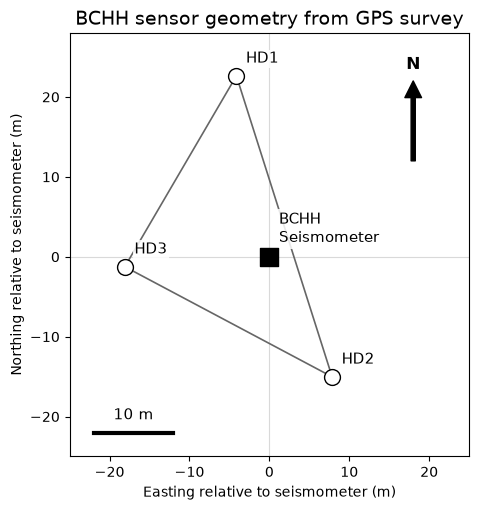

In [2]:
"""
Make Falcon 9 / BCHH location figures.

Outputs:
  fig01a_slc40_bchh_map.png/pdf
  fig01b_bchh_array_geometry.png/pdf
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional map dependencies
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point, LineString
from pyproj import Geod


OUTDIR = Path("figures")
OUTDIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------------
# Coordinates from Table S2
# ---------------------------------------------------------------------

SLC40 = {
    "name": "SLC-40",
    "lat": 28.56195,
    "lon": -80.57719,
}

BCHH_SENSORS = pd.DataFrame(
    [
        {
            "sensor": "Seismometer",
            "channel": "HHE/HN/HZ",
            "easting_m": 541820.43,
            "northing_m": 3160866.50,
            "lat": 28.5740171,
            "lon": -80.572375,
            "rel_elev_m": 0.0,
        },
        {
            "sensor": "HD1",
            "channel": "Infrasound 1",
            "easting_m": 541816.30,
            "northing_m": 3160889.14,
            "lat": 28.574222,
            "lon": -80.572417,
            "rel_elev_m": -0.12,
        },
        {
            "sensor": "HD2",
            "channel": "Infrasound 2",
            "easting_m": 541828.28,
            "northing_m": 3160851.47,
            "lat": 28.573881,
            "lon": -80.572296,
            "rel_elev_m": -0.23,
        },
        {
            "sensor": "HD3",
            "channel": "Infrasound 3",
            "easting_m": 541802.34,
            "northing_m": 3160865.25,
            "lat": 28.574006,
            "lon": -80.572560,
            "rel_elev_m": 0.17,
        },
    ]
)

BCHH = {
    "name": "BCHH",
    "lat": BCHH_SENSORS.loc[BCHH_SENSORS.sensor == "Seismometer", "lat"].iloc[0],
    "lon": BCHH_SENSORS.loc[BCHH_SENSORS.sensor == "Seismometer", "lon"].iloc[0],
}


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def save_figure(fig, basename):
    for ext in ("png", "pdf"):
        fig.savefig(OUTDIR / f"{basename}.{ext}", dpi=300, bbox_inches="tight")


def add_simple_scalebar(ax, length_km=1.0, location=(0.62, 0.92), linewidth=4):
    """
    Draws a simple approximate scale bar in EPSG:3857 axes.
    """
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    x = x0 + location[0] * (x1 - x0)
    y = y0 + location[1] * (y1 - y0)
    length_m = length_km * 1000.0

    ax.plot([x, x + length_m], [y, y], color="black", lw=linewidth, solid_capstyle="butt")
    ax.plot([x, x], [y - 80, y + 80], color="black", lw=linewidth)
    ax.plot([x + length_m, x + length_m], [y - 80, y + 80], color="black", lw=linewidth)
    ax.text(
        x + length_m / 2,
        y + 140,
        f"{length_km:g} km",
        ha="center",
        va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
    )


def add_north_arrow(ax, location=(0.93, 0.86), size=0.08):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    x = x0 + location[0] * (x1 - x0)
    y = y0 + location[1] * (y1 - y0)
    dy = size * (y1 - y0)

    ax.annotate(
        "",
        xy=(x, y + dy),
        xytext=(x, y),
        arrowprops=dict(facecolor="black", edgecolor="black", width=4, headwidth=14),
    )
    ax.text(x, y + dy * 1.12, "N", ha="center", va="bottom", fontsize=13, fontweight="bold")


# ---------------------------------------------------------------------
# Figure 1A: SLC-40 to BCHH regional geometry
# ---------------------------------------------------------------------

def make_regional_map():
    geod = Geod(ellps="WGS84")
    az12, az21, dist_m = geod.inv(SLC40["lon"], SLC40["lat"], BCHH["lon"], BCHH["lat"])

    rows = [
        {"name": "SLC-40", "kind": "pad", "geometry": Point(SLC40["lon"], SLC40["lat"])},
        {"name": "BCHH", "kind": "station", "geometry": Point(BCHH["lon"], BCHH["lat"])},
    ]

    gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326").to_crs("EPSG:3857")

    line = gpd.GeoDataFrame(
        [{"geometry": LineString([Point(SLC40["lon"], SLC40["lat"]), Point(BCHH["lon"], BCHH["lat"])])}],
        crs="EPSG:4326",
    ).to_crs("EPSG:3857")

    fig, ax = plt.subplots(figsize=(6.5, 6.0))

    # Plot line first
    line.plot(ax=ax, color="black", linewidth=1.5, linestyle="-", zorder=3)

    # Plot symbols
    pads = gdf[gdf.kind == "pad"]
    stations = gdf[gdf.kind == "station"]

    pads.plot(ax=ax, marker="^", markersize=180, color="yellow", edgecolor="black", zorder=5)
    stations.plot(ax=ax, marker="o", markersize=120, color="black", edgecolor="black", zorder=5)

    # Labels
    for _, row in gdf.iterrows():
        x, y = row.geometry.x, row.geometry.y
        ax.text(
            x + 120,
            y + 80,
            row["name"],
            fontsize=12,
            ha="left",
            va="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1),
            zorder=6,
        )

    # Distance label
    mid = line.geometry.iloc[0].interpolate(0.5, normalized=True)
    ax.text(
        mid.x + 80,
        mid.y,
        f"{dist_m/1000:.2f} km\naz. {az12:.0f}°",
        fontsize=11,
        ha="left",
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1),
        zorder=6,
    )

    # Map extent
    xmin, ymin, xmax, ymax = gdf.total_bounds
    pad = 900
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution_size=8)

    add_simple_scalebar(ax, length_km=1.0, location=(0.58, 0.93))
    add_north_arrow(ax)

    ax.set_title("SLC-40 to BCHH station geometry", fontsize=14)
    ax.set_axis_off()

    save_figure(fig, "fig01a_slc40_bchh_map")
    return fig, ax


# ---------------------------------------------------------------------
# Figure 1B: BCHH local array geometry from Table S2
# ---------------------------------------------------------------------

def make_array_geometry():
    df = BCHH_SENSORS.copy()

    ref = df[df.sensor == "Seismometer"].iloc[0]
    df["x_m"] = df["easting_m"] - ref["easting_m"]
    df["y_m"] = df["northing_m"] - ref["northing_m"]

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    # Infrasound triangle
    infra = df[df.sensor.str.startswith("HD")]
    tri = infra.sort_values("sensor")
    tri_closed = pd.concat([tri, tri.iloc[[0]]])
    ax.plot(tri_closed["x_m"], tri_closed["y_m"], color="0.4", lw=1.2, zorder=1)

    # Plot instruments
    ax.scatter(infra["x_m"], infra["y_m"], s=130, facecolor="white", edgecolor="black", zorder=3)
    seis = df[df.sensor == "Seismometer"]
    ax.scatter(seis["x_m"], seis["y_m"], s=150, marker="s", color="black", zorder=4)

    # Labels
    for _, row in df.iterrows():
        label = row["sensor"]
        if row["sensor"] == "Seismometer":
            label = "BCHH\nSeismometer"
        ax.text(
            row["x_m"] + 1.2,
            row["y_m"] + 1.2,
            label,
            fontsize=11,
            ha="left",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1),
        )

    # Scale bar
    x0, y0 = -22, -22
    ax.plot([x0, x0 + 10], [y0, y0], color="black", lw=3)
    ax.text(x0 + 5, y0 + 1.2, "10 m", ha="center", va="bottom", fontsize=11)

    # North arrow
    ax.annotate(
        "",
        xy=(18, 22),
        xytext=(18, 12),
        arrowprops=dict(facecolor="black", edgecolor="black", width=3, headwidth=12),
    )
    ax.text(18, 23, "N", ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.axhline(0, color="0.85", lw=0.8, zorder=0)
    ax.axvline(0, color="0.85", lw=0.8, zorder=0)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Easting relative to seismometer (m)")
    ax.set_ylabel("Northing relative to seismometer (m)")
    ax.set_title("BCHH sensor geometry from GPS survey", fontsize=14)

    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 28)

    save_figure(fig, "fig01b_bchh_array_geometry")
    return fig, ax, df



make_regional_map()
fig, ax, df_offsets = make_array_geometry()
print(df_offsets[["sensor", "channel", "x_m", "y_m", "rel_elev_m"]])
plt.show()